In [2]:
import os
import sys

import ast
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
import tensorflow as tf
import time
import xgboost as xgb

from ahrs.filters import Madgwick, Mahony
from pprint import pprint
from scipy import signal
from scipy.signal import find_peaks
from scipy.ndimage import median_filter
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA, PLSRegression
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, f1_score, mean_squared_error, 
                             precision_score, recall_score)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import OneClassSVM
from tensorflow.keras import layers, Model
from tensorflow.keras import layers, models,regularizers
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (BatchNormalization, Conv1D, Dense, Dropout, 
                                     Flatten, LSTM, MaxPooling1D,RepeatVector, RepeatVector, 
                                     Reshape, TimeDistributed, UpSampling1D)
from tensorflow.keras.models import Sequential, load_model
from keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, Adamax, RMSprop, SGD
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.utils import Sequence
import tensorflow.keras.backend as K
from tensorflow.keras.models import load_model

# Working on the raw data between 18Hz - 20Hz  frecuency

## Matching Data and clining it. 
We have Nicla Data where its the row Robotarm data. There ist the normal functionality and the anomaly behavior. 
It will be clining the stundby data (where the sensor Environment "Nicla") start to sensing but the Robot arm have not starting to work.
1. Clining stops (Null)
2. Detecting and separte the anomaly and health data

In [221]:
# Generate Nicla dataframe, perform initial checks.
# If local the path:
nicla_path = "P_CAS/Data_Robotarm/nicla.csv"

# We skip first 6 rows due to faulty format/data.
nicla = pd.read_csv(nicla_path, on_bad_lines='warn', skiprows=6, 
                    names=["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "MagX", "MagY", "MagZ"])

# Check if there are any empty/Nan variables. 
if nicla.isnull().values.any():
    raise ValueError("Nan variable is present.")

# Explore the dataframe.
print(nicla.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1751682 entries, 0 to 1751681
Data columns (total 9 columns):
 #   Column  Dtype  
---  ------  -----  
 0   AccX    float64
 1   AccY    float64
 2   AccZ    float64
 3   GyroX   float64
 4   GyroY   float64
 5   GyroZ   float64
 6   MagX    float64
 7   MagY    float64
 8   MagZ    float64
dtypes: float64(9)
memory usage: 120.3 MB
None


## Visualazation of the row Data Nicla

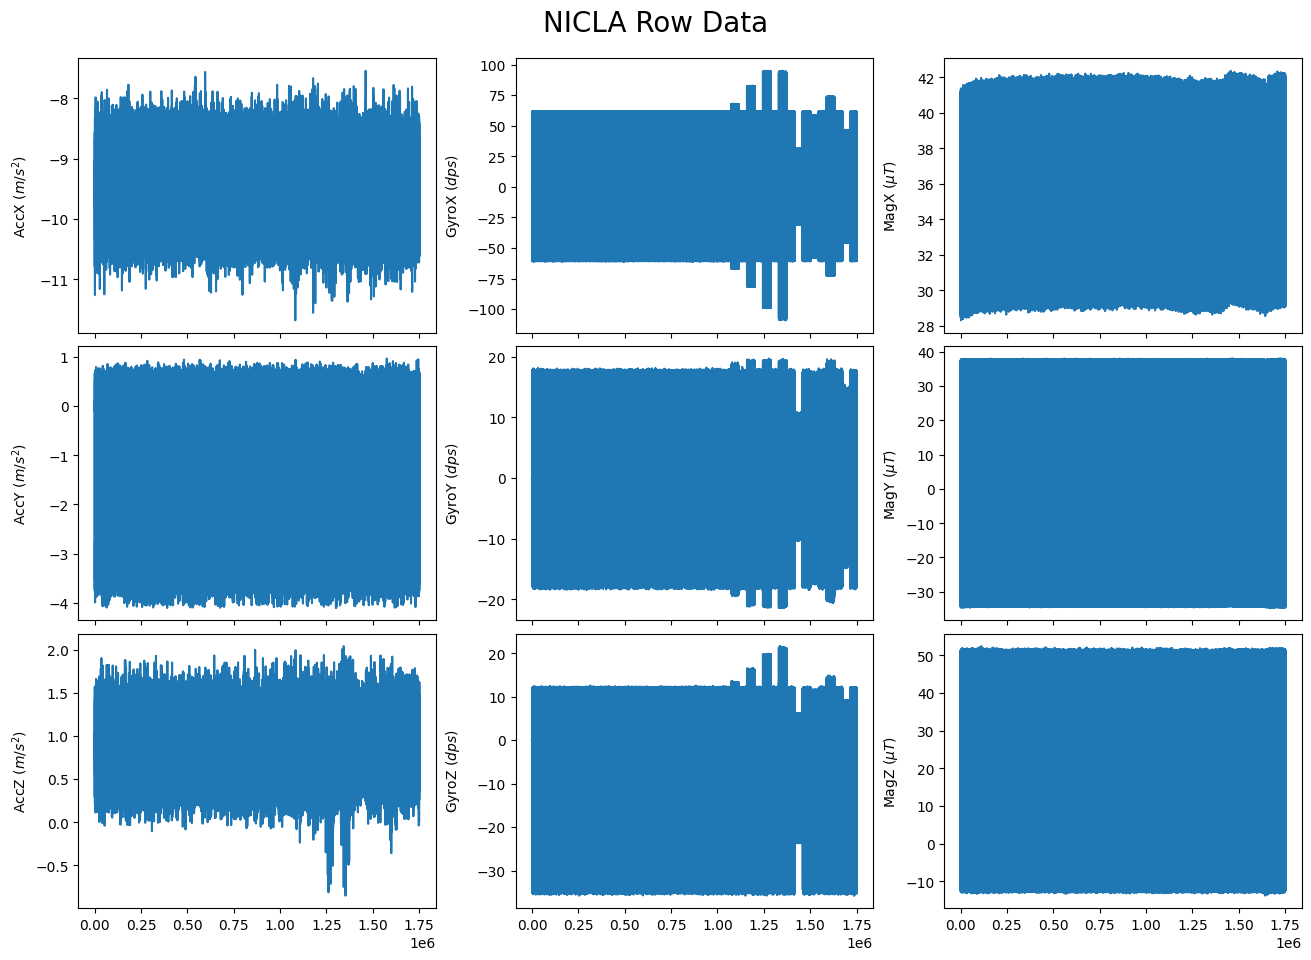

In [18]:
# Visualize the first 1000 point
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, sharex = True, figsize=(13, 9), constrained_layout=True)

start_index = 0
end_index = 1000

ax1.plot(nicla.index, nicla['AccX'])
ax1.set_ylabel(r'AccX $(m/s^2)$')

ax2.plot(nicla.index, nicla['GyroX'])
ax2.set_ylabel(r'GyroX $(dps)$')

ax3.plot(nicla.index, nicla['MagX'])
ax3.set_ylabel(r'MagX (${\mu}T$)')

ax4.plot(nicla.index, nicla['AccY'])
ax4.set_ylabel(r'AccY $(m/s^2)$')

ax5.plot(nicla.index, nicla['GyroY'])
ax5.set_ylabel(r'GyroY $(dps)$')

ax6.plot(nicla.index, nicla['MagY'])
ax6.set_ylabel(r'MagY (${\mu}T$)')

ax7.plot(nicla.index, nicla['AccZ'])
ax7.set_ylabel(r'AccZ $(m/s^2)$')

ax8.plot(nicla.index, nicla['GyroZ'])
ax8.set_ylabel(r'GyroZ $(dps)$')

ax9.plot(nicla.index, nicla['MagZ'])
ax9.set_ylabel(r'MagZ (${\mu}T$)')

fig.align_labels()
plt.suptitle("NICLA Row Data", x = 0.5, y = 1.05, fontsize = 20)
fig.savefig("Graphics/NICLA Row Data.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [104]:
# Using the GyroX to find where the robot start to move, noise occurs at range of 0 < x < 1, so we find the first point where x >= 1
index = np.argmax(nicla['GyroX'][:].diff().abs() >= 1)
print(f"The movement starts at {index}.")

The movement starts at 898.


# Now We can remove the first pice of the date, The Robot arm its untill this point not moving 

In [222]:
nicla_dropped = nicla.iloc[897:].reset_index(drop=True)
print(f"The length of the nicla data is {len(nicla_dropped)}")



The length of the nicla data is 1750785


In [19]:
# Visualize the first 1000 head of the dataframe.
show_data = nicla.head(100)
show_data

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagX,MagY,MagZ
0,-9.72285,-0.01676,0.88825,0.1875,0.0000,0.0000,33.16,-30.52,6.92308
1,-9.68933,-0.00479,0.88585,0.0625,0.0625,0.0000,33.20,-30.56,6.76923
2,-9.70131,-0.04070,0.85952,0.0000,0.0000,0.0625,33.28,-30.68,6.69231
3,-9.71328,-0.02155,0.88585,-0.1250,0.0000,-0.0625,33.32,-30.80,6.76923
4,-9.71567,-0.01676,0.87388,0.0000,0.0000,0.1250,33.12,-30.68,6.84615
...,...,...,...,...,...,...,...,...,...
95,-9.72285,-0.01197,0.86191,-0.2500,0.0000,-0.0625,33.28,-30.52,6.92308
96,-9.70131,-0.05267,0.85952,0.0000,-0.0625,0.0000,33.08,-30.52,6.38462
97,-9.66539,-0.04310,0.88107,0.0000,0.0000,-0.1250,32.96,-30.56,6.61538
98,-9.72525,0.00000,0.86191,0.0625,0.0000,0.0000,33.08,-30.64,6.92308


Having a frecuency of 20Hz, the total data points in 24 Hrs to be collected is:  
print(60 * 60 * 20 * 24) = 1728000 points
Now its possible to find when started the Fail data point, because the Data (right_arm), who has a faliur label

In [224]:
# Load the dataframe for the right arm. 
right_arm = pd.read_csv("P_CAS/Data_Robotarm/right_arm.csv", on_bad_lines='warn')

# Check if there are any empty/Nan variables. 
if right_arm.isnull().values.any():
    raise ValueError("Nan variable is present.")

# Reset Timestamp to 0.
right_arm["Timestamp"] = right_arm["Timestamp"] - right_arm["Timestamp"][0]
print(right_arm.info())
print(f"The length of the Right_arm data is {len(right_arm)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1762650 entries, 0 to 1762649
Data columns (total 20 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   Timestamp                          float64
 1   Actual Joint Positions             object 
 2   Actual Joint Velocities            object 
 3   Actual Joint Currents              object 
 4   Actual Cartesian Coordinates       object 
 5   Actual Tool Speed                  object 
 6   Generalized Forces                 object 
 7   Temperature of Each Joint          object 
 8   Execution Time                     float64
 9   Safety Status                      int64  
 10  Tool Acceleration                  object 
 11  Norm of Cartesion Linear Momentum  float64
 12  Robot Current                      float64
 13  Joint Voltages                     object 
 14  Elbow Position                     object 
 15  Elbow Velocity                     object 
 16  Tool Current      

Identifying the Fail data point with the Right_arm data["Anomaly State "]

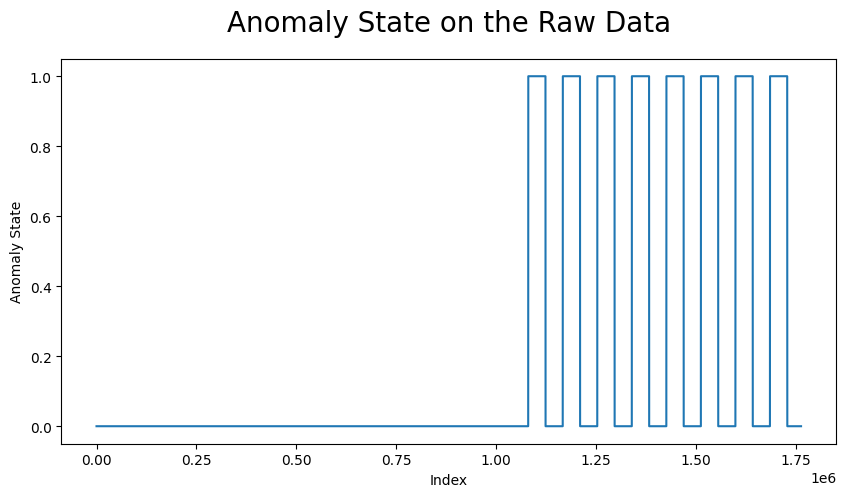

In [107]:
fig = plt.figure(figsize = (10,5))
plt.plot(right_arm.index,right_arm["Anomaly State"])
plt.xlabel('Index')
plt.ylabel('Anomaly State')
plt.title("Anomaly State on the Raw Data", x = 0.5, y = 1.05, fontsize = 20)
fig.savefig("Graphics/Anomaly_NN_Raw_Data.pdf", format='pdf', bbox_inches='tight')

With the Graphic "Anomaly State on the Raw Data" its possible to separate the anomaly data and make a labeling

In [225]:
# Find the first anomaly point.
df_labels = right_arm["Anomaly State"]
idx_f = (df_labels== 1.0).idxmax()
# Find the Lasta anomaly ponit.
index_list = np.where(df_labels == 1)
index_of_last_one = index_list[0][-1]
print(f"The first anomaly point in Arm_data is located at {idx_f}.")
print(f"The final anomaly pointin Arm_data is located at: {index_of_last_one}")

The first anomaly point in Arm_data is located at 1080004.
The final anomaly pointin Arm_data is located at: 1728006


Remembering the lenght of the data for 20Hz --> 1728000 points its possible to match and Truncate the "right_arm" Data.
Now coming to defin the anomaly and health data on the Nicla data.

In [226]:
# The data ist Truncated
right_arm = right_arm[0:1728000]

# Data points that we know its normal on Nicla data
df_gyroX = nicla_dropped["GyroX"]
# Convert into numpy array.
gyroX = df_gyroX.to_numpy()
gyroX_N = gyroX[0:1000000]
# Anomaly data on the Nicla data

gyroX_A = gyroX[1000000:]

#Defin min and max of the normal data
gyroX_N_min = np.min(gyroX_N)
gyroX_N_max = np.max(gyroX_N)

# Find the Raw data either bigger than "Nomarl Maximal" & "Nomarl Minimal"
greater_indices = np.argwhere(gyroX > gyroX_N_max)
lesser_indices = np.argwhere(gyroX < gyroX_N_min)

# The first greater point and the last minimal point
first_greater_index = greater_indices[0][0]
last_lesser_index = lesser_indices[-1][0]
print(f"The first greater point is located at: {first_greater_index}")
print(f"The last lesser point is located at: {last_lesser_index}")

The first greater point is located at: 1072794
The last lesser point is located at: 1629872


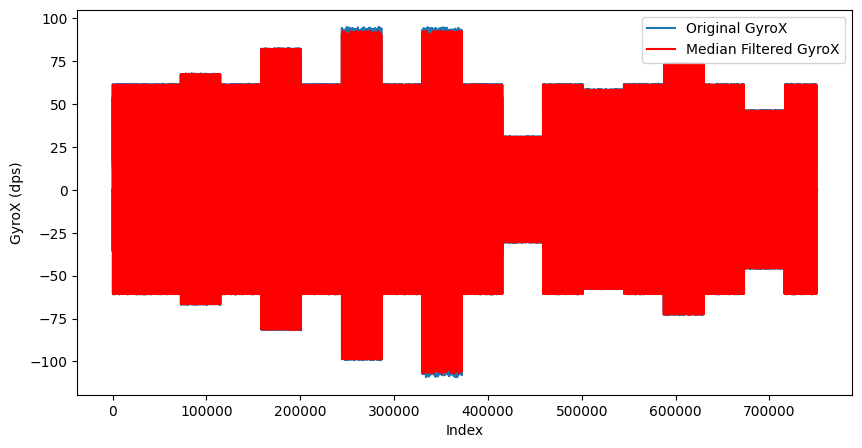

the last index of gyroX_median is: 750784


In [227]:
# Applying the Median Filter to the GyroX data, and visualize the result.
gyroX_median = median_filter(gyroX_A, cval=0, mode='constant', size=3)
fig = plt.figure(figsize = (10,5))
plt.plot(gyroX_A, label='Original GyroX')
plt.plot(gyroX_median, label='Median Filtered GyroX', color='red')
plt.xlabel('Index')
plt.ylabel('GyroX (dps)')
plt.legend()
plt.show()
print(f"the last index of gyroX_median is: {len(gyroX_median)-1}")



Supposition 1.1
We take the suppost that this Anomalus behaviour could be anticipate or predict for a Machine Learning model (The model could be learn about this anomaly)

In [228]:
#Seprate interval of the data gyroX_median 0<gyroX_median<72000 to find the POC of the movement, and to find the treshold for the anomaly detection
gyroX_median_int_1 = gyroX_median[:72000]
gyroX_median_nor = gyroX_median_int_1[:1900]
# To have the principal POC on the gyrox_median
max_gyroX_median = np.max(gyroX_median_int_1)
min_gyroX_median = np.min(gyroX_median_int_1)
#standard deviation beford the Picn
sigma=np.std(gyroX_median_nor)
#umbral detection
treshold = gyroX_median_nor[0] + 3*sigma
#Find the first point that is bigger than the treshold
index_treshold = np.argmax(gyroX_median_int_1 > treshold)
print(f"The maximum value of the median filtered first Int GyroX is: {max_gyroX_median}")
print(f"The minimum value of the anomaly in GyroX is: {min_gyroX_median}")
print(f"The index of the first point above the threshold is: {index_treshold}")
print(f"The value in the anomaly over the threshold is: {gyroX_median_int_1[index_treshold]}")
print("treshold value is: ", treshold)

The maximum value of the median filtered first Int GyroX is: 61.625
The minimum value of the anomaly in GyroX is: -60.6875
The index of the first point above the threshold is: 340
The value in the anomaly over the threshold is: 60.875
treshold value is:  60.858006042773454


It is Creating an intervall to labeling the anomaly data, with moving media to smoth the curve. We take a periodic interval each 43.000 data points, betwing the intervals label theare 30.000 data points (interval each 1 minute aprox, at 20Hz ).


The length of the Nicla Data 1750785


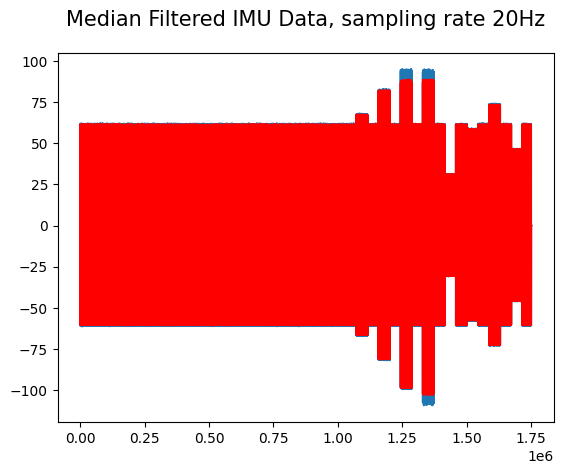

In [231]:
#separate normal and anomaly data on nicla data, since the first maximal anomalous point (index 1072794)
nicla_normal = nicla_dropped[0:1072794]
nicla_anomaly = nicla_dropped[1072794:]


f_window_size = 6


# Critic: The size must be odd for centered median filtering.
if f_window_size % 2 == 0:
    f_window_size += 1



# Apply moving median and convert back to numpy array for faster ops.
nicla_filtered_normal = nicla_normal.rolling(f_window_size, center=True).median()
nicla_filtered_anomaly = nicla_anomaly.rolling(f_window_size, center=True).median()

nicla_filtered_normal = nicla_filtered_normal.fillna(nicla_normal).dropna().to_numpy()
nicla_filtered_anomaly = nicla_filtered_anomaly.fillna(nicla_anomaly).dropna().to_numpy()

#concatenate the normal and anomaly data
nicla_filtered = np.concatenate((nicla_filtered_normal, nicla_filtered_anomaly), axis=0)
nicla_dropped_f = np.concatenate((nicla_normal, nicla_anomaly), axis=0)

# Create a numpy array that will hold anomaly labels. 
len_nicla = len(nicla_filtered)
print(f"The length of the Nicla Data {len_nicla}")

# Plot the labels for a visual check.
plt.plot(nicla_dropped_f[:, 3], label='GyroX normal')
plt.plot(nicla_filtered[:, 3], label='GyroX anomaly', color='red')
plt.title("Median Filtered IMU Data, sampling rate 20Hz", x = 0.5, y = 1.05, fontsize = 15)
plt.show()


In [113]:
#maximal and minimal of the normal data
max_normal = np.max(nicla_filtered_normal)
min_normal = np.min(nicla_filtered_normal)
max_anomali = np.max(nicla_filtered_anomaly)
min_anomali = np.min(nicla_filtered_anomaly)
#index of the maximal and minimal of the normal data
index_max_normal = np.argmax(nicla_filtered_normal)
index_min_normal = np.argmin(nicla_filtered_normal)
print(f"The maximal value of the normal data is: {max_normal}")
print(f"The minimal value of the normal data is: {min_normal}")
print(f"The maximal value of the anomaly data is: {max_anomali}")
print(f"The minimal value of the anomaly data is: {min_anomali}")
print(f"The index of the maximal value of the normal data is: {index_max_normal}")
print(f"The index of the minimal value of the normal data is: {index_min_normal}")

The maximal value of the normal data is: 61.4375
The minimal value of the normal data is: -60.625
The maximal value of the anomaly data is: 88.8125
The minimal value of the anomaly data is: -102.875
The index of the maximal value of the normal data is: 924834
The index of the minimal value of the normal data is: 260148


Creat a correlation matrix, to find the interrelation betwing variables 

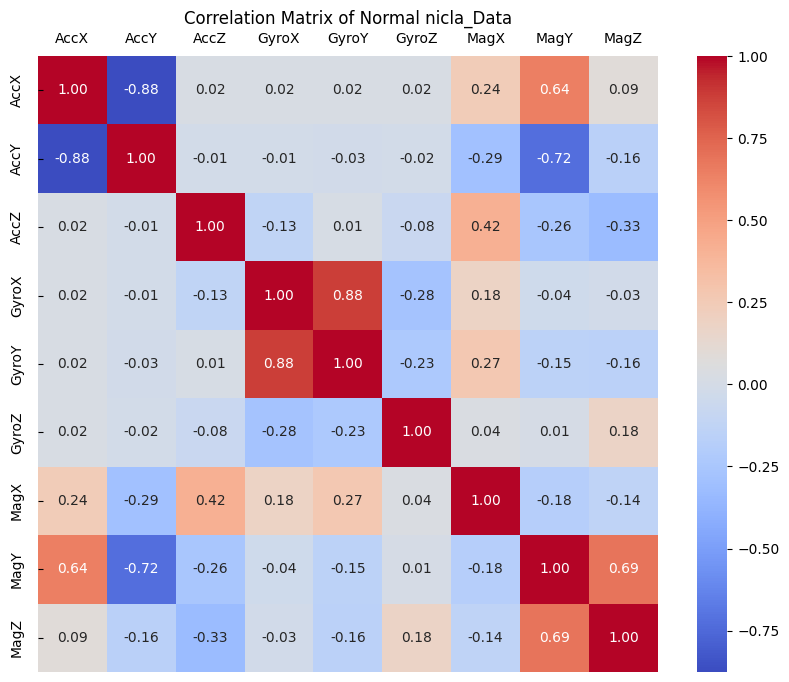

In [ ]:
corr_matrix = np.corrcoef(nicla_filtered_normal.T)
#feature selection based on correlation
np_accX = nicla_filtered_normal[:, 0]
np_accY = nicla_filtered_normal[:, 1]
np_accZ = nicla_filtered_normal[:, 2]
np_gyroX = nicla_filtered_normal[:, 3]
np_gyroY = nicla_filtered_normal[:, 4]
np_gyroZ = nicla_filtered_normal[:, 5]
np_magX = nicla_filtered_normal[:, 6]
np_magY = nicla_filtered_normal[:, 7]
np_magZ = nicla_filtered_normal[:, 8]

# Set labels.
tick_labels = ["AccX", "AccY", "AccZ",
               "GyroX", "GyroY", "GyroZ",
               "MagX", "MagY", "MagZ"]

# Plot the correlation matrix with tick labels.
plt.figure(figsize=(10, 8))
M_Corr=sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=tick_labels, yticklabels=tick_labels)
M_Corr.yaxis.set_tick_params(pad=10, direction='in', labelleft=True, labelright=False)
M_Corr.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=True)
plt.title("Correlation Matrix of Normal nicla_Data")
plt.show()

There are between GyroX and GyroY, AccY and MagY highly correlate.

Nexte step will be split the data set für training, testing and validating

In [ ]:
# Spliting the data into training, validation and test sets.

total_length = nicla_filtered_normal.shape[0]
train_end = int(total_length * 0.3)
val_end = int(total_length * 0.2)

train_data = nicla_filtered_normal[train_end:]
validation_data = nicla_filtered_normal[:val_end]
test_data = nicla_filtered_normal[val_end:train_end ]

# Scaling
scaler_X = StandardScaler().fit(train_data)
X_train, X_val, X_test, X_anol,nicla_all = [pd.DataFrame(scaler_X.transform(data).astype('float32'), 
                                  columns=["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "MagX", "MagY", "MagZ"]) 
                                  for data in [train_data, validation_data, test_data, nicla_filtered_anomaly,nicla_filtered]]



def create_windows(data, window_size=255, sliding_number=1):
    windows = np.lib.stride_tricks.sliding_window_view(
        data, window_size, axis=0
    )[::sliding_number]
    return windows.swapaxes(1, 2)


# windos creation on the dataframes, and convert to numpy arrays for faster ops.

X_train_windows = create_windows(X_train.to_numpy())
X_train_target = create_windows(train_data)
X_val_windows = create_windows(X_val.to_numpy())
X_val_target = create_windows(validation_data)
X_test_windows = create_windows(X_test.to_numpy())
X_test_target = create_windows(test_data)
X_anol_windows = create_windows(X_anol.to_numpy())
nicla_anol_windows = create_windows(nicla_filtered_anomaly)
nicla_all_windows = create_windows(nicla_all.to_numpy())


In [119]:
#number of zero on the Date
zero_count_all_windos = np.sum(X_test == 0)
print(f"The number of zero values in the X_test is: {zero_count_all_windos}")

The number of zero values in the X_test is: AccX     0
AccY     0
AccZ     0
GyroX    0
GyroY    0
GyroZ    0
MagX     0
MagY     0
MagZ     0
dtype: int64


/Users/juliano/P_Robotarm/P_CAS/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


(1750785, 9)
0


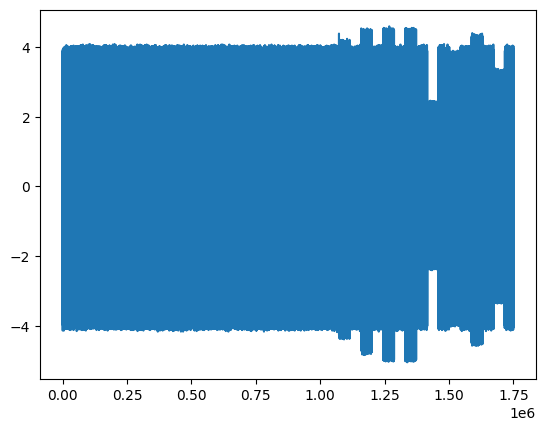

In [120]:
# Lokkign for NaN values and the shape of the data after windowing.
print(nicla_all.shape)

print(np.isnan(nicla_all_windows).sum())

plt.plot(nicla_all_windows[:,1,4], label='GyroX normal')
plt.show()

## Applying Autoencoder for the Anomaly detection
The idea its tu detect de anomaly that where found it manualy on the Anomaly data, but with the Autoencoder

In [ ]:
MAX_EPOCHS = 40
NUM_FILTERS = 16
NUM_FEATURES = 9
WINDOW_SIZE = 300

#TIMESTEPS=len(X_train_windows)


def create_model(TIMESTEPS, NUM_FEATURES):
    
    model = Sequential()
    model.add(LSTM(NUM_FILTERS, activation='tanh', input_shape=(TIMESTEPS,NUM_FEATURES), dropout=0.2))
    model.add(RepeatVector(TIMESTEPS))
    model.add(LSTM(NUM_FILTERS, activation='tanh', return_sequences=True, dropout=0.2))
    model.add(Flatten())
    
    model.add(Dense(NUM_FEATURES*TIMESTEPS)) ,  # Dense layer to reshape the output
    model.add(Reshape((TIMESTEPS, NUM_FEATURES)))  # Reshape back to the original shape
    
    #model.add(TimeDistributed(Dense(9)))
    model.compile(optimizer=RMSprop(learning_rate=0.001), loss='mse')
    return model






In [ ]:
# Main execution
if __name__ == "__main__":

  

    # Create and train model
    autoencoder = create_model(WINDOW_SIZE, NUM_FEATURES)
    
    # Define early stopping and learning rate reduction callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
    #autoencoder.compile(optimizer=RMSprop(learning_rate=0.002), loss='mse')
    history_lstm_encoder = autoencoder.fit(X_train_windows, X_train_target, epochs=MAX_EPOCHS, batch_size=256, validation_data=(X_val_windows, X_val_target), callbacks=[early_stopping,reduce_lr],shuffle=False, verbose=1)
    


In [ ]:
#Save the trained model
autoencoder.save("LSTM_Encoder_430Windows_Medmov5.keras")

In [ ]:
#Load teh trained model
autoencoder = load_model("Models_LSTM_Encoder_200Windows.keras")

In [ ]:
### Extracting loss and validation loss
train_loss_lstm_ae = history_lstm_encoder.history['loss']
val_loss_lstm_ae = history_lstm_encoder.history['val_loss']
epochs = range(1, len(train_loss_lstm_ae) + 1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss_lstm_ae, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss_lstm_ae, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('Graphics/rmse__lstm_AE_model_2.pdf', format='pdf')
plt.show()


In [ ]:

def prepare_data(data, window_size=100):
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data.reshape(-1, 1))
    X = np.array([data_scaled[i:i+window_size] for i in range(len(data_scaled) - window_size)])
    return X, scaler



def Treshold_calculat(reconstruction_error):
   
    
    treshold=np.percentile(reconstruction_error, 99.6)
    return treshold



# Predict and calculate reconstruction error

X_pred_val = autoencoder.predict(X_anol_windows)
MSE_nical_val = np.mean((X_anol_windows - X_pred_val ) ** 2, axis=(1,2))
#RMSE
#rmse_reconstruction = np.sqrt(MSE_nical)

# Detect anomalies
Treshold = Treshold_calculat(MSE_nical_val)

# Predict anonmalies on the entire dataset
X_pred = autoencoder.predict(nicla_all_windows)
MSE_nical= np.mean((nicla_all_windows - X_pred ) ** 2, axis=(1,2))


anomalies =MSE_nical > Treshold 

## Ploting anomaly detection 
with AE, sequential() function

In [ ]:
# Plotting detection

def plot_results(data, anomalies):
    plt.figure(figsize=(12, 6))
    
    # Plot the original data
    
    plt.plot(data["GyroX"], label="Time Series",zorder=1)
    
    # Detect anomalies
    #mean = np.mean(reconstruction_error)
    #std = np.std(reconstruction_error)
    #anomalies =reconstruction_error > threshold*std + mean
    
    # Plot anomalies
    anomaly_indices = np.where(anomalies)[0]
    
    plt.scatter(anomaly_indices, data["GyroX"].iloc[anomaly_indices], s=20, color='red', label="Anomalies", zorder=2)
    
    
    plt.title("Anomaly Detection with LSTM Autoencoder")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.savefig('lstm_anomaly_detection.jpg')
    plt.show()
    
    return anomalies
#Original label feature on data

#Data Frame convert and colummn adding
#def df_columns_to_list(df):
    df=pd.DataFrame(df)
    df.reset_index(drop=True,inplace=True)
    df.columns=[list(nicla.columns.values)]
    return df


# Plot results
plot_results(nicla_all, anomalies)

print(f"Number of anomalies detected 40 Epochs, 99,5% Percentile: {np.sum(anomalies)}")


In [121]:
# Set hyperparameters
window_size = 255
num_features = 9
num_filters = 32
conv_width = 3
max_pool_size = 3

def model_CNN_AE(timesteps, num_features, num_filters,conv_width,max_pool_size):

    # Encoder
    
    model = Sequential()
    model.add(Conv1D(num_filters, activation='relu', kernel_size=(conv_width), input_shape=(timesteps, num_features),padding='same'))
    model.add(MaxPooling1D(pool_size=max_pool_size, padding='same'))
    model.add(Conv1D(num_filters, activation='relu', padding='same', kernel_size=(conv_width)))
  
    #Decoder


    model.add(Conv1D(num_filters, activation='relu', padding='same', kernel_size=(conv_width)))
    model.add(UpSampling1D(size=max_pool_size))
    model.add(Conv1D(num_features, activation='relu', padding='same', kernel_size=(conv_width)))
    model.add(Flatten())
    
    model.add(Dense(num_features*timesteps)) ,  # Dense layer to reshape the output
    model.add(Reshape((timesteps, num_features)))  # Reshape back to the original shape
    model.compile(optimizer=RMSprop(learning_rate=0.001), loss='mse')
    return model




In [122]:
#CNN_Autoencoder execution
if __name__ == "__main__":

  

    # Create and train model
    CNN_autoencoder = model_CNN_AE(window_size, num_features, num_filters, conv_width, max_pool_size)
    
    # Define early stopping and learning rate reduction callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
  

# Fit the model CNN_AE

    history_CNN_encoder = CNN_autoencoder.fit(X_train_windows, X_train_windows, epochs=40, batch_size=256, validation_data=(X_val_windows, X_val_windows), callbacks=[early_stopping,reduce_lr],shuffle=False, verbose=1)
    CNN_autoencoder.save("CNN_Autoencoder_W6.keras")

/Users/juliano/P_Robotarm/P_CAS/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 56s 19ms/step - loss: 0.0602 - val_loss: 0.0392 - learning_rate: 0.0010
Epoch 2/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 53s 18ms/step - loss: 0.0281 - val_loss: 0.0281 - learning_rate: 0.0010
Epoch 3/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 54s 18ms/step - loss: 0.0190 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 4/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 60s 21ms/step - loss: 0.0162 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 5/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 63s 21ms/step - loss: 0.0145 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 6/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 61s 21ms/step - loss: 0.0135 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 7/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 60s 21ms/step - loss: 0.0128 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 8/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 60s 20ms/step - loss: 0.0122 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 9/40
2933/2933 ━━━━━━━━━━━━━━━━━━━━ 60s 21ms/step - loss: 0.0118 - val_loss: 0.013

In [ ]:
#Load teh trained model
CNN_autoencoder = load_model("CNN_Autoencoder_W6.keras")

In [127]:
def Treshold_calculat(reconstruction_error):
   
    
    treshold=np.percentile(reconstruction_error, 99.8)
    return treshold



# Predict and calculate reconstruction error

X_pred_val = CNN_autoencoder.predict(X_val_windows)
MSE_nical_val = np.mean((X_val_windows - X_pred_val ) ** 2, axis=(1,2))
#RMSE
#rmse_reconstruction = np.sqrt(MSE_nical)

# Detect anomalies
Treshold = Treshold_calculat(MSE_nical_val)

# Predict anonmalies on the entire dataset
X_pred = CNN_autoencoder.predict(nicla_all_windows)
MSE_nical= np.mean((nicla_all_windows - X_pred ) ** 2, axis=(1,2))

zero_ratio=np.sum(nicla_all_windows == 0, axis=(1,2))  

anomalies = (MSE_nical > Treshold) & (zero_ratio < 0.5)

6697/6697 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
54705/54705 ━━━━━━━━━━━━━━━━━━━━ 70s 1ms/step


In [1]:
import matplotlib.pyplot as plt

# Set up figure and hide axes
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis("off")

# LaTeX formula string
formula = r"$\tau = P_{99.8} \left( \frac{1}{W \cdot F} \sum_{i=1}^{W} \sum_{j=1}^{F} \left( \mathbf{X}_{i,j} - \hat{\mathbf{X}}_{i,j} \right)^2 \right)$"

# Render equation in high resolution
ax.text(
    0.5,
    0.5,
    formula,
    fontsize=22,
    ha="center",
    va="center",
    transform=ax.transAxes,
)

# Save as PNG
plt.savefig("threshold_formula.png", dpi=300, bbox_inches="tight", transparent=True)
plt.close()

print("Formula successfully saved as 'threshold_formula.png'!")

Formula successfully saved as 'threshold_formula.png'!


Number of anomalies detected 40 Epochs, 99,6% Percentile, CNN_AE: 127368


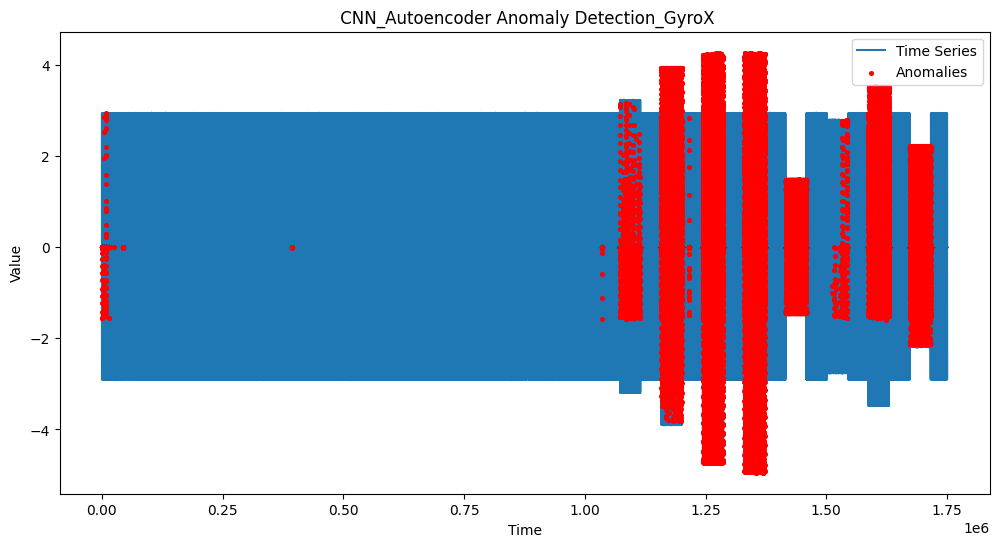

Number of anomalies detected 40 Epochs CNN_AE, 96%Percentile_Wind15: 127368


In [128]:
#Print the anomalies detected
print(f"Number of anomalies detected 40 Epochs, 99,6% Percentile, CNN_AE: {np.sum(anomalies)}")

def plot_results(data, anomalies):
    plt.figure(figsize=(12, 6))
    
    # Plot the original data
    
    plt.plot(data["GyroX"], label="Time Series",zorder=1)
    
    # Detect anomalies
    #mean = np.mean(reconstruction_error)
    #std = np.std(reconstruction_error)
    #anomalies =reconstruction_error > threshold*std + mean
    
    # Plot anomalies
    anomaly_indices = np.where(anomalies)[0]
    
    plt.scatter(anomaly_indices, data["GyroX"].iloc[anomaly_indices], s=7, color='red', label="Anomalies", zorder=2)
    
    
    plt.title(" CNN_Autoencoder Anomaly Detection_GyroX")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.savefig('lstm_anomaly_detection.jpg')
    plt.show()
    
    return anomalies
#Original label feature on data

#Data Frame convert and colummn adding
#def df_columns_to_list(df):
    df=pd.DataFrame(df)
    df.reset_index(drop=True,inplace=True)
    df.columns=[list(nicla.columns.values)]
    return df


# Plot results
plot_results(nicla_all, anomalies)

print(f"Number of anomalies detected 40 Epochs CNN_AE, 96%Percentile_Wind15: {np.sum(anomalies)}")
save_path = "Graphics/Anomaly_Detection_CNN_AE_Wind15.jpg"

# Hibrid Model


 We have five diferents Failur that has a kontrolled origin in a laboratori. 
 - Earthquake
 - Extra Weight
 - Hitting on the plataform
 - Hitting on the Arm
 - Magnet field close to the Arm

## The objective its working with a representative healthing data to train the model and then evaluat the diferents failurs, looking for a good acuracy and prediction of the anomaly behaviour 
With a IMU 10Hz Data we'll preprocessing and clining, looking for a representative normal behaviour of the robot arm. 
After to slpit the data and creat a windows partition of the data to improve the anomaly prediction we shall proceed to evaluate the Faliur 


In [9]:
# Generate dataframe, perform initial checks.

# Define local the path:
Path_IMU_10 = "P_CAS/Data_Robotarm/IMU_10Hz.csv"

# We skip first 6 rows due to faulty format/data.
DATA_IMU_10 = pd.read_csv(Path_IMU_10, on_bad_lines='warn', skiprows=(1,11))

In [12]:
# Info dataframe.
print(DATA_IMU_10.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 874935 entries, 0 to 874934
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   name    874935 non-null  object 
 1   time    874935 non-null  int64  
 2   accX    874935 non-null  float64
 3   accY    874935 non-null  float64
 4   accZ    874935 non-null  float64
 5   gyroX   874935 non-null  float64
 6   gyroY   874935 non-null  float64
 7   gyroZ   874935 non-null  float64
 8   magX    874935 non-null  float64
 9   magY    874935 non-null  float64
 10  magZ    874935 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 73.4+ MB
None


In [13]:
# Visualize the first 1000 head of the dataframe.
show_data = DATA_IMU_10.head(100)
show_data

,name,time,accX,accY,accZ,gyroX,gyroY,gyroZ,magX,magY,magZ
0,IMU8,1686062828537000000,9.806650,0.263362,0.488417,0.0625,0.0000,0.0000,-48.279999,-7.44,-13.230769
1,IMU8,1686062828585000000,9.794679,0.251391,0.442927,-0.1875,0.0000,0.0000,-48.560001,-7.48,-13.230769
2,IMU8,1686062828682000000,9.770737,0.222661,0.445322,-0.0625,0.0625,0.0000,-48.520000,-7.32,-13.461538
3,IMU8,1686062828780000000,9.792285,0.222661,0.464475,0.0000,0.0000,0.0000,-48.360001,-7.28,-13.692307
4,IMU8,1686062828878000000,9.787497,0.244209,0.500388,-0.1250,-0.0625,0.0000,-48.200001,-7.56,-14.000000
...,...,...,...,...,...,...,...,...,...,...,...
95,IMU8,1686062838092000000,9.794679,0.275333,0.500388,-0.0625,-0.0625,0.0000,-48.200001,-7.36,-13.076923
96,IMU8,1686062838189000000,9.849746,0.277727,0.509965,0.0000,0.1250,0.1875,-48.200001,-7.60,-13.153846
97,IMU8,1686062838335000000,9.809044,0.332794,0.440533,0.1250,0.0000,0.1250,-47.959999,-7.48,-13.153846
98,IMU8,1686062838432000000,9.823409,0.253785,0.476446,-0.0625,0.0000,0.0000,-48.279999,-7.64,-12.615385


# Visualization

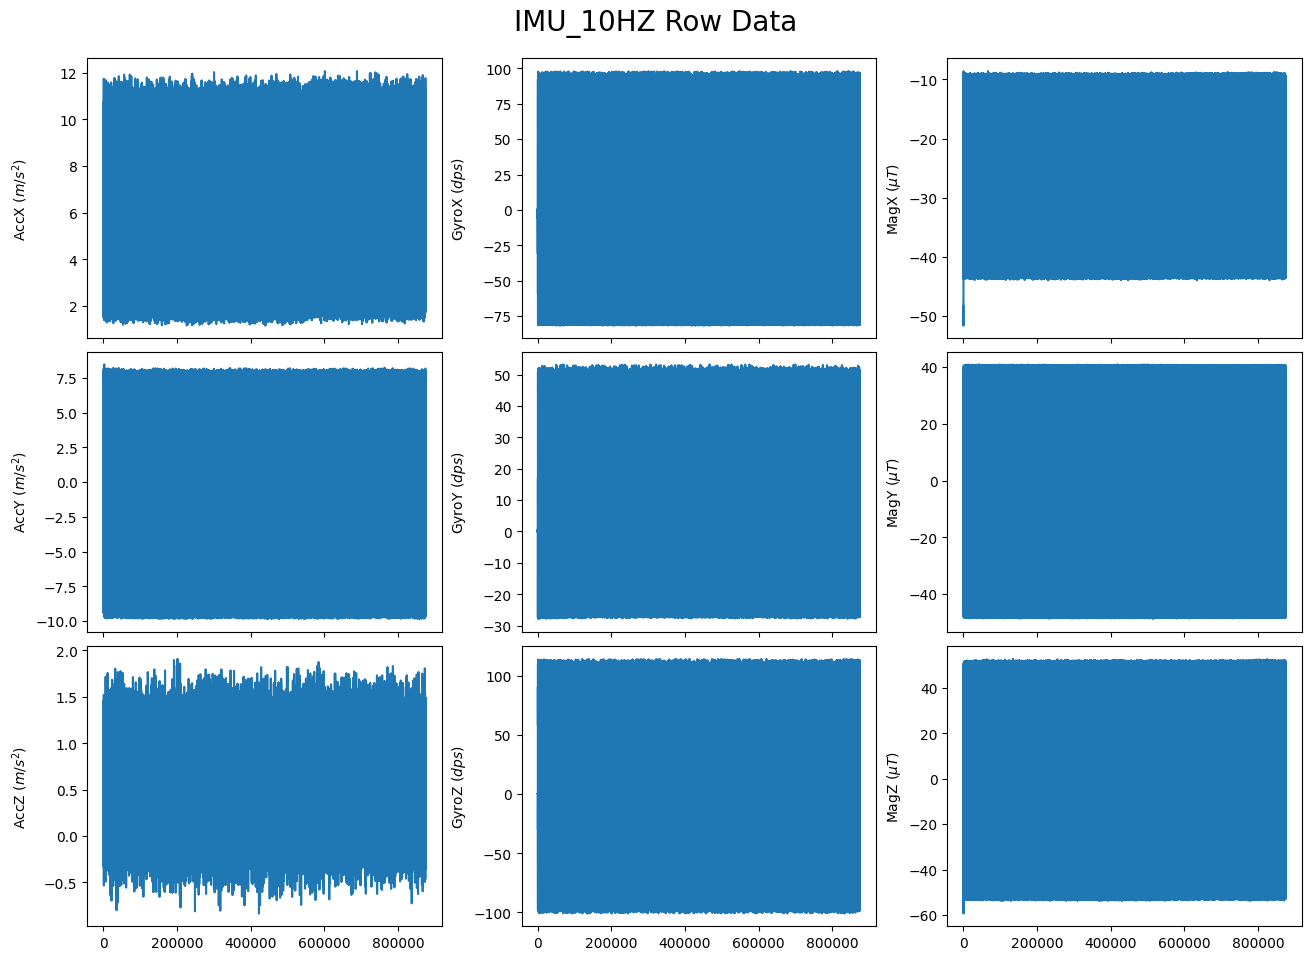

In [15]:
# Visualize the first 1000 point
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, sharex = True, figsize=(13, 9), constrained_layout=True)


ax1.plot(DATA_IMU_10.index, DATA_IMU_10['accX'])
ax1.set_ylabel(r'AccX $(m/s^2)$')

ax2.plot(DATA_IMU_10.index, DATA_IMU_10['gyroX'])
ax2.set_ylabel(r'GyroX $(dps)$')

ax3.plot(DATA_IMU_10.index, DATA_IMU_10['magX'])
ax3.set_ylabel(r'MagX (${\mu}T$)')

ax4.plot(DATA_IMU_10.index, DATA_IMU_10['accY'])
ax4.set_ylabel(r'AccY $(m/s^2)$')

ax5.plot(DATA_IMU_10.index, DATA_IMU_10['gyroY'])
ax5.set_ylabel(r'GyroY $(dps)$')

ax6.plot(DATA_IMU_10.index, DATA_IMU_10['magY'])
ax6.set_ylabel(r'MagY (${\mu}T$)')

ax7.plot(DATA_IMU_10.index, DATA_IMU_10['accZ'])
ax7.set_ylabel(r'AccZ $(m/s^2)$')

ax8.plot(DATA_IMU_10.index, DATA_IMU_10['gyroZ'])
ax8.set_ylabel(r'GyroZ $(dps)$')

ax9.plot(DATA_IMU_10.index, DATA_IMU_10['magZ'])
ax9.set_ylabel(r'MagZ (${\mu}T$)')

fig.align_labels()
plt.suptitle("IMU_10HZ Row Data", x = 0.5, y = 1.05, fontsize = 20)
fig.savefig("Graphics_Hibrid/All_Features_IMU10Hz.pdf", format='pdf', bbox_inches='tight')
plt.show()



# First impresion
The first impression its to fine a pick on the starting period, which is normal wen some process beginning to work


Text(0.5, 1.05, 'MagX on the IMU_10HZ Data')

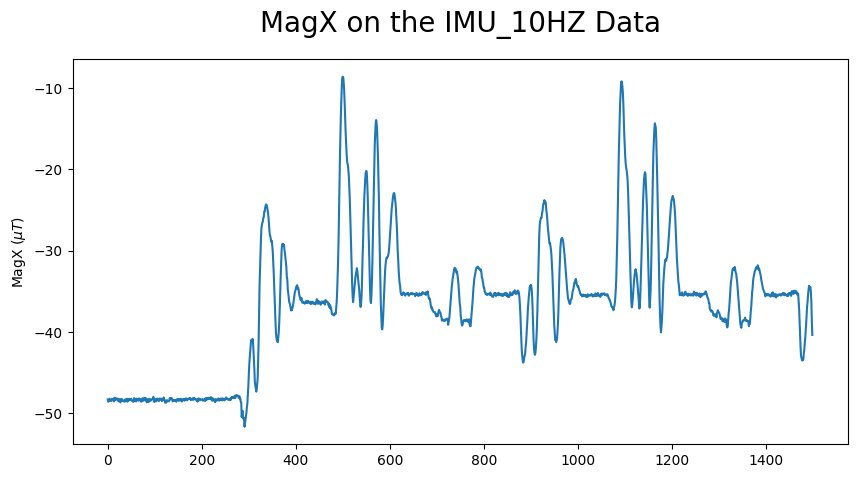

In [16]:
# Find the first pick period on the MagX
Index_i = 0
Index_f = 1500
# Exploratory range
fig, ax3 = plt.subplots(figsize=(10, 5))

ax3.plot(DATA_IMU_10.index[Index_i:Index_f], DATA_IMU_10['magX'][Index_i:Index_f])
ax3.set_ylabel(r'MagX (${\mu}T$)')
#plot

fig.savefig("Graphics_Hibrid/MagX on the IMU_10HZ Data.pdf", format='pdf', bbox_inches='tight')

#plot fig
plt.title("MagX on the IMU_10HZ Data", x = 0.5, y = 1.05, fontsize = 20)


# Cleaning Process 

 - We drop the features that doesn't provide information for the first explotatorie process
 - If we see the MagX nad MagZ its possible see that the starting process generate a pick that its normal to happens, so we clean it also
 

In [17]:
# Dropping some inecesary Feature 
DATA_IMU_10.drop(columns=['name', 'time'], inplace=True)

# Dropping the period where the machine started and the become normal behaviour, has we saw on the las graphic, that the normality start at the point 320
DATA_IMU_10=DATA_IMU_10.iloc[320:]

DATA_IMU_10.reset_index(drop=True, inplace=True)

print(DATA_IMU_10.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 874615 entries, 0 to 874614
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   accX    874615 non-null  float64
 1   accY    874615 non-null  float64
 2   accZ    874615 non-null  float64
 3   gyroX   874615 non-null  float64
 4   gyroY   874615 non-null  float64
 5   gyroZ   874615 non-null  float64
 6   magX    874615 non-null  float64
 7   magY    874615 non-null  float64
 8   magZ    874615 non-null  float64
dtypes: float64(9)
memory usage: 60.1 MB
None


# Signal Review
-  Evaluate with a media filtered and a sigma signal how big its the noise

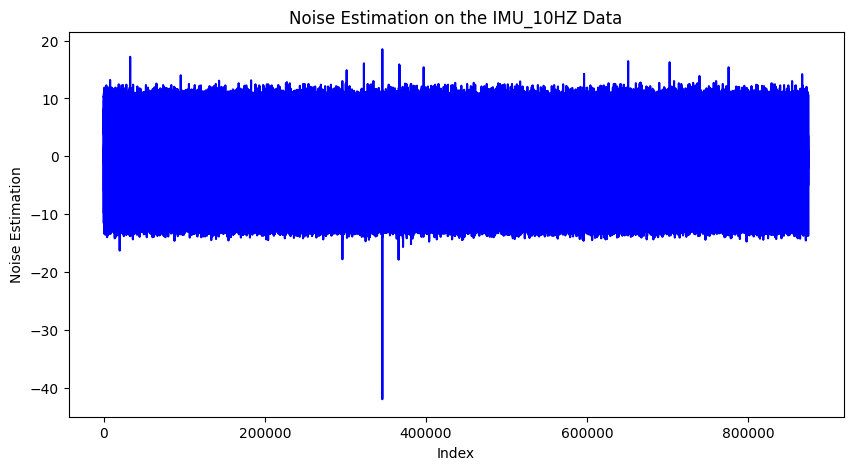

In [18]:
from scipy.signal import medfilt
 # Apply a filter per column, using a kernel size of 5

DATA_IMU_10_filtered= DATA_IMU_10.apply(lambda x: medfilt(x, kernel_size=5))

# noise estimation Delta
noise=DATA_IMU_10- DATA_IMU_10_filtered 


# Graphic of the noise estimation
fig, f_noise = plt.subplots(figsize=(10, 5))
f_noise.plot(noise, label='Noise Estimation', color='blue')
f_noise.set_ylabel(r'Noise Estimation')
f_noise.set_xlabel(r'Index')

fig.savefig("Graphics_Hibrid/Noise Estimation on the IMU_10HZ Data.pdf", format='pdf', bbox_inches='tight')
plt.title("Noise Estimation on the IMU_10HZ Data",  ha='center')
plt.show()

# The noise on the Data for some features could be high 
- for that reason we used a Moving Media

In [19]:
#media filtered data
f_window_size = 6


# Critic: The size must be odd for centered median filtering.
if f_window_size % 2 == 0:
    f_window_size += 1



# Apply moving median and convert back to numpy array for faster operations.

DATA_IMU_10_MM_FILTERED = DATA_IMU_10.rolling(f_window_size, center=True).median()


DATA_IMU_10_MM_FILTERED = DATA_IMU_10_MM_FILTERED.fillna(DATA_IMU_10).dropna().to_numpy()

/Users/juliano/P_Robotarm/P_CAS/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


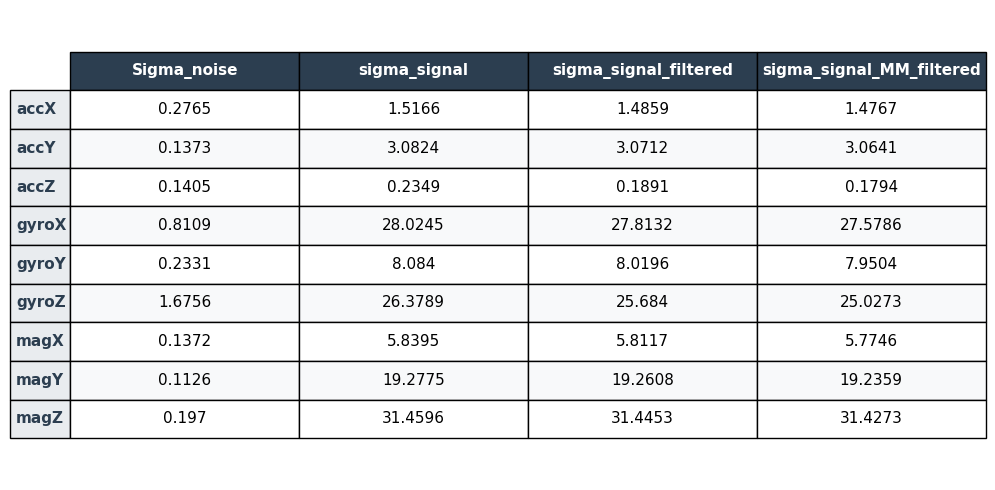

In [25]:
#compare tabel 
Sigma_noise=np.std(noise) # Standard deviation of the noise
sigma_signal=np.std(DATA_IMU_10) # Standard deviation of the signal
sigma_signal_filtered=np.std(DATA_IMU_10_filtered) # Standard deviation of the filtered signal
sigma_signal_MM_filtered=np.std(DATA_IMU_10_MM_FILTERED,axis=0) # Standard deviation of the filtered signal



#Table between the noise and the signal
summary=pd.DataFrame({'Sigma_noise': Sigma_noise, 'sigma_signal': sigma_signal, 'sigma_signal_filtered': sigma_signal_filtered, 'sigma_signal_MM_filtered': sigma_signal_MM_filtered}).round(4)



# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    rowLabels=summary.index,
    cellLoc='center',
    loc='center'
)

# Set base font size and scale
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 1.9)

# Apply visual formatting to header, row labels, and alternating rows
for (row, col), cell in table.get_celld().items():
    # Header row (column titles)
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    # Row labels (index column)
    elif col == -1:
        cell.set_text_props(weight='bold', color='#2c3e50')
        cell.set_facecolor('#e9ecef')
    # Data cells with alternating row colors
    else:
        cell.set_facecolor('#f8f9fa' if row % 2 == 0 else '#ffffff')

plt.tight_layout()
plt.savefig('styled_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()

fig.savefig("Graphics_Hibrid/Compering the noise with the filter data.pdf", format='pdf', bbox_inches='tight')



# Feature correlation Review 
- generate a Correlation Matriz 

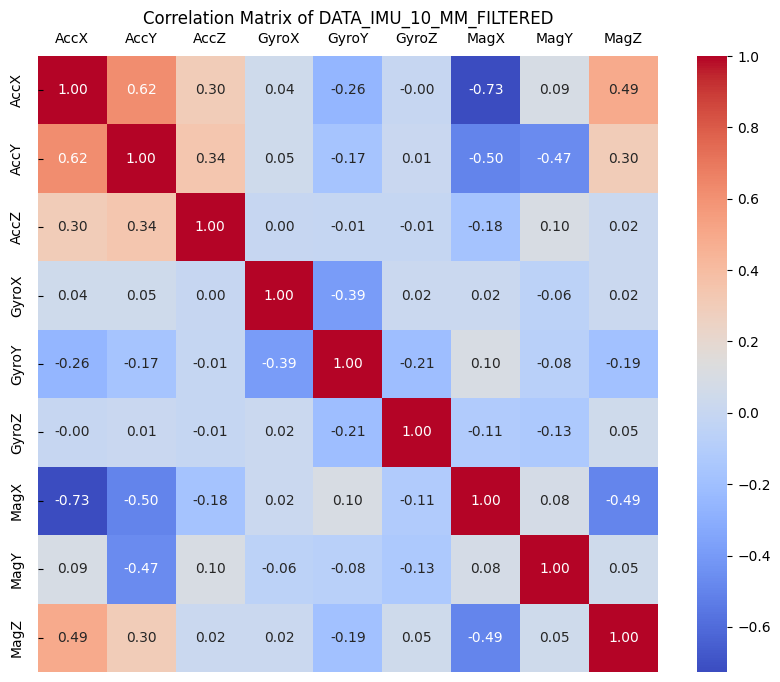

In [171]:
Corr_matrix = np.corrcoef(DATA_IMU_10_MM_FILTERED.T)
#feature selection based on correlation
np_accX = DATA_IMU_10_MM_FILTERED[:, 0]
np_accY = DATA_IMU_10_MM_FILTERED[:, 1]
np_accZ = DATA_IMU_10_MM_FILTERED[:, 2]
np_gyroX = DATA_IMU_10_MM_FILTERED[:, 3]
np_gyroY = DATA_IMU_10_MM_FILTERED[:, 4]
np_gyroZ = DATA_IMU_10_MM_FILTERED[:, 5]
np_magX = DATA_IMU_10_MM_FILTERED[:, 6]
np_magY = DATA_IMU_10_MM_FILTERED[:, 7]
np_magZ = DATA_IMU_10_MM_FILTERED[:, 8]

# Set tick labels.
tick_labels = ["AccX", "AccY", "AccZ",
               "GyroX", "GyroY", "GyroZ",
               "MagX", "MagY", "MagZ"]
# Plot the correlation matrix with tick labels.
plt.figure(figsize=(10, 8))
M_Corr=sns.heatmap(Corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=tick_labels, yticklabels=tick_labels)
M_Corr.yaxis.set_tick_params(pad=10, direction='in', labelleft=True, labelright=False)
M_Corr.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=True)
plt.title("Correlation Matrix of DATA_IMU_10_MM_FILTERED")
plt.show()

# Charging the Data with Faliure
- exploring the diferents Faliur Data

In [26]:
df_earthquake = pd.read_csv('P_CAS/Data_Robotarm/IMU_earthquake.csv', header=None)
df_hitting_arm = pd.read_csv('P_CAS/Data_Robotarm/IMU_hitting_arm.csv', header=None)
df_hitting_platform = pd.read_csv('P_CAS/Data_Robotarm/IMU_hitting_platform.csv', header=None)
df_extra_weight = pd.read_csv('P_CAS/Data_Robotarm/IMU_extra_weigth.csv', header=None)
df_magnet = pd.read_csv('P_CAS/Data_Robotarm/IMU_magnet.csv', header=None)
print(df_extra_weight.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       10886 non-null  object
 1   1       10886 non-null  object
 2   2       10886 non-null  object
 3   3       10886 non-null  object
 4   4       10886 non-null  object
 5   5       10886 non-null  object
 6   6       10886 non-null  object
 7   7       10886 non-null  object
 8   8       10886 non-null  object
 9   9       10886 non-null  object
 10  10      10886 non-null  object
dtypes: object(11)
memory usage: 935.6+ KB
None


In [11]:
# print head 10 rows
df_earthquake.head(10)

,0,1,2,3,4,5,6,7,8,9,10
0,name,time,accX,accY,accZ,gyroX,gyroY,gyroZ,magX,magY,magZ
1,IMU22,1695908152746000000,9.84495735168457,-0.0071826050989329815,0.004788403399288654,0,0,0,0,0,0
2,IMU22,1695908152843000000,9.842562675476074,-0.009576806798577309,0.019153613597154617,0,0.125,-0.1875,-36.119998931884766,29.959999084472656,8.15384578704834
3,IMU22,1695908152941000000,9.799467086791992,-0.0454898327589035,0.026336219161748886,-0.0625,0.125,0,-36.08000183105469,29.920000076293945,7.615384578704834
4,IMU22,1695908153038000000,9.830592155456543,-0.028730420395731926,0,0,0,0,-36.31999969482422,29.760000228881836,8
5,IMU22,1695908153136000000,9.856927871704102,-0.028730420395731926,0.031124621629714966,0,0,0,-36.31999969482422,29.8799991607666,8.15384578704834
6,IMU22,1695908153283000000,9.823409080505371,-0.033518824726343155,0,-0.0625,0,0,-36.20000076293945,29.8799991607666,7.538461685180664
7,IMU22,1695908153380000000,9.854534149169922,-0.011971008032560349,0.019153613597154617,0,0,-0.0625,-36.2400016784668,29.959999084472656,8.461538314819336
8,IMU22,1695908153429000000,9.828197479248047,-0.009576806798577309,0.0454898327589035,-0.0625,-0.0625,0,-36.2400016784668,29.959999084472656,7.692307472229004
9,IMU22,1695908153526000000,9.84735107421875,-0.028730420395731926,0.021547814831137657,0,-0.125,0,-36.279998779296875,29.959999084472656,7.384615421295166


# # Dropping the columns and the row, they are not needed for the analysis, for each Data Faliure 

In [27]:
# cleaning the Failure dataframe 

# Earthquake dataframe cleaning
df_earthquake=df_earthquake.drop(columns=[0, 1]).iloc[1:].reset_index(drop=True)
df_earthquake.columns = range(df_earthquake.shape[1])
df_earthquake = df_earthquake.apply(pd.to_numeric, errors='coerce')
# Hitting arm dataframe cleaning
df_hitting_arm=df_hitting_arm.drop(columns=[0, 1]).iloc[1:].reset_index(drop=True)
df_hitting_arm.columns = range(df_hitting_arm.shape[1])
df_hitting_arm = df_hitting_arm.apply(pd.to_numeric, errors='coerce')
# Hitting platform dataframe cleaning
df_hitting_platform=df_hitting_platform.drop(columns=[0, 1]).iloc[1:].reset_index(drop=True)
df_hitting_platform.columns = range(df_hitting_platform.shape[1])
df_hitting_platform = df_hitting_platform.apply(pd.to_numeric, errors='coerce')
# Extra weight dataframe cleaning
df_extra_weight=df_extra_weight.drop(columns=[0, 1]).iloc[1:].reset_index(drop=True)
df_extra_weight.columns = range(df_extra_weight.shape[1])
df_extra_weight = df_extra_weight.apply(pd.to_numeric, errors='coerce')
# Magnet dataframe cleaning
df_magnet=df_magnet.drop(columns=[0, 1]).iloc[1:].reset_index(drop=True)
df_magnet.columns = range(df_magnet.shape[1])
df_magnet = df_magnet.apply(pd.to_numeric, errors='coerce')


In [28]:
# Verifying the Nan values of the dataframe.
if df_magnet.isnull().sum().sum() > 0:
    print("There are NaN values in the dataframe.")

print(np.isnan(df_magnet).sum())

print(df_magnet.info())


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15118 entries, 0 to 15117
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       15118 non-null  float64
 1   1       15118 non-null  float64
 2   2       15118 non-null  float64
 3   3       15118 non-null  float64
 4   4       15118 non-null  float64
 5   5       15118 non-null  float64
 6   6       15118 non-null  float64
 7   7       15118 non-null  float64
 8   8       15118 non-null  float64
dtypes: float64(9)
memory usage: 1.0 MB
None


In [29]:
# Setting the features names for the dataframe
features_names = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "MagX", "MagY", "MagZ"]
df_earthquake.columns = features_names
df_hitting_arm.columns = features_names
df_hitting_platform.columns = features_names
df_extra_weight.columns = features_names
df_magnet.columns = features_names
df_magnet.head(10)


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagX,MagY,MagZ
0,9.842563,-0.088585,0.038307,0.0625,-0.1250,-0.0625,-13.96,14.20,-174.461533
1,9.844957,-0.117316,0.004788,-0.0625,0.0000,0.1250,-13.84,14.12,-174.692307
2,9.832986,-0.086191,0.023942,0.0625,0.0000,0.0000,-13.88,14.32,-174.615387
3,9.847351,-0.052672,0.019154,0.0000,0.0000,0.0000,-13.88,14.12,-174.307693
4,9.842563,-0.074220,0.031125,0.0625,-0.1250,0.0000,-13.80,13.92,-173.769226
5,9.816227,-0.076614,0.016759,0.0000,-0.1875,0.0000,-13.84,14.24,-174.538467
6,9.832986,-0.074220,-0.021548,0.0000,-0.0625,0.0000,-14.12,13.88,-174.538467
7,9.840169,-0.112527,0.021548,-0.0625,-0.0625,-0.0625,-14.28,14.08,-174.384613
8,9.835381,-0.086191,0.021548,0.0625,0.0000,0.0625,-14.04,14.04,-174.846161
9,9.861716,-0.031125,0.002394,0.0625,0.0625,0.0000,-14.04,14.04,-174.692307


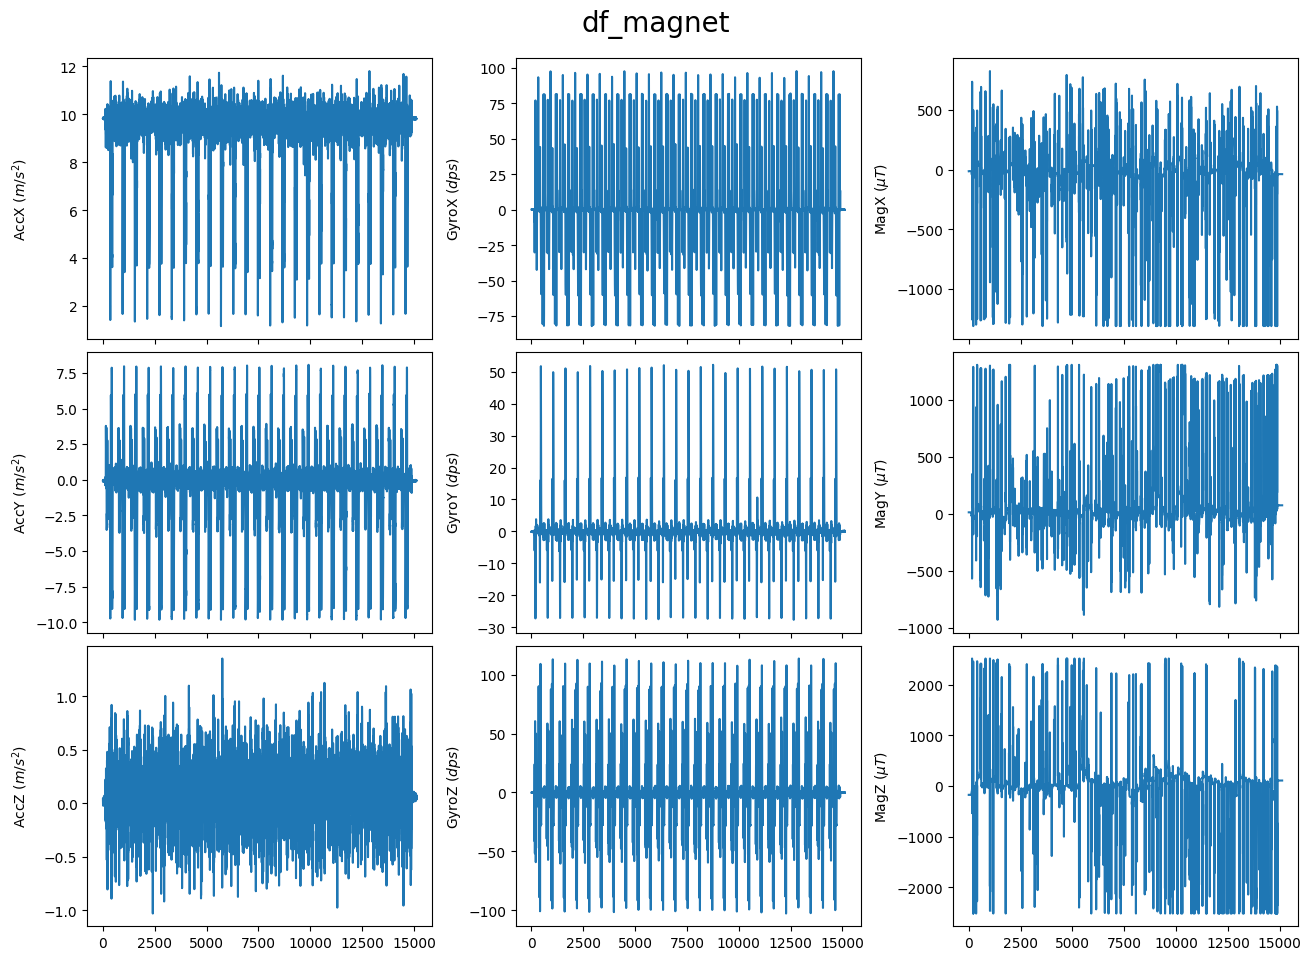

In [31]:
# Generate graphic for the faliure data 

# Visualize the first 1000 point
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, sharex = True, figsize=(13, 9), constrained_layout=True)


ax1.plot(df_magnet.index, df_magnet['AccX'])
ax1.set_ylabel(r'AccX $(m/s^2)$')

ax2.plot(df_magnet.index, df_magnet['GyroX'])
ax2.set_ylabel(r'GyroX $(dps)$')

ax3.plot(df_magnet.index, df_magnet['MagX'])
ax3.set_ylabel(r'MagX (${\mu}T$)')

ax4.plot(df_magnet.index, df_magnet['AccY'])
ax4.set_ylabel(r'AccY $(m/s^2)$')

ax5.plot(df_magnet.index, df_magnet['GyroY'])
ax5.set_ylabel(r'GyroY $(dps)$')

ax6.plot(df_magnet.index, df_magnet['MagY'])
ax6.set_ylabel(r'MagY (${\mu}T$)')

ax7.plot(df_magnet.index, df_magnet['AccZ'])
ax7.set_ylabel(r'AccZ $(m/s^2)$')

ax8.plot(df_magnet.index, df_magnet['GyroZ'])
ax8.set_ylabel(r'GyroZ $(dps)$')

ax9.plot(df_magnet.index, df_magnet['MagZ'])
ax9.set_ylabel(r'MagZ (${\mu}T$)')

fig.align_labels()
plt.suptitle("df_magnet", x = 0.5, y = 1.05, fontsize = 20)
fig.savefig("Graphics_Hibrid/Failure_magnet.pdf", format='pdf', bbox_inches='tight')
plt.show()



# Spliting the IMU_10Hz Data to Training the moel

In [32]:
total_length = DATA_IMU_10_MM_FILTERED.shape[0] # DATA_IMU_10_MM_FILTERED ist the Normal datra to train the model
train_end = int(total_length * 0.6)
val_end = int(total_length * 0.8)

train_data = DATA_IMU_10_MM_FILTERED[:train_end]      # 0-60%
validation_data = DATA_IMU_10_MM_FILTERED[train_end:val_end]  # 60-80%
test_data = DATA_IMU_10_MM_FILTERED[val_end:]         # 80-100%

# Scaling with the train data
scaler_X = StandardScaler().fit(train_data)


datasets = {
    'train': train_data,
    'val': validation_data,
    'test': test_data,
    'earthquake': df_earthquake,
    'hitting_arm': df_hitting_arm,
    'hitting_platform': df_hitting_platform,
    'extra_weight': df_extra_weight,
    'magnet': df_magnet
}

scaled_datasets = {}
for name, data in datasets.items():
    arr = data.values if hasattr(data, 'values') else data
    scaled_datasets[name] = pd.DataFrame(
        scaler_X.transform(arr),
        columns=["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "MagX", "MagY", "MagZ"]
    )

# Scaling Data for the train, validation, test, and failure datasets

X_train = scaled_datasets['train']
X_val = scaled_datasets['val']
X_test = scaled_datasets['test']
Falure_erq = scaled_datasets['earthquake']
Falure_hit = scaled_datasets['hitting_arm']
Falure_plat = scaled_datasets['hitting_platform']
Falure_weight = scaled_datasets['extra_weight']
Falure_magnet = scaled_datasets['magnet']



In [95]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524769 entries, 0 to 524768
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AccX    524769 non-null  float64
 1   AccY    524769 non-null  float64
 2   AccZ    524769 non-null  float64
 3   GyroX   524769 non-null  float64
 4   GyroY   524769 non-null  float64
 5   GyroZ   524769 non-null  float64
 6   MagX    524769 non-null  float64
 7   MagY    524769 non-null  float64
 8   MagZ    524769 non-null  float64
dtypes: float64(9)
memory usage: 36.0 MB
None


In [33]:


# CREATE SLIDING WINDOWS


def create_windows(df, window_size=20, step=20):
    """Convierte un DataFrame de N muestras x 9 canales en ventanas 3D (muestras, window_size, 9)"""
    data = df.values
    windows = []
    for i in range(0, len(data) - window_size + 1, step):
        windows.append(data[i : i + window_size])
    return np.array(windows)

WINDOW_SIZE = 20  # size of the sliding window
STEP = 20          # Traslapeoverlap) between windows

# 1. Ventanas para data normal (Autoencoder)
train_win = create_windows(X_train, WINDOW_SIZE, STEP)
val_win = create_windows(X_val, WINDOW_SIZE, STEP)
test_win = create_windows(X_test, WINDOW_SIZE, STEP)

# 2. windows for the failure data
erq_win = create_windows(Falure_erq, WINDOW_SIZE, STEP)
hit_win = create_windows(Falure_hit, WINDOW_SIZE, STEP)
plat_win = create_windows(Falure_plat, WINDOW_SIZE, STEP)
weight_win = create_windows(Falure_weight, WINDOW_SIZE, STEP)
magnet_win = create_windows(Falure_magnet, WINDOW_SIZE, STEP)

# concatenate and labeling the failure windows (Clases: 0, 1, 2, 3, 4)
X_failures = np.concatenate([erq_win, hit_win, plat_win, weight_win, magnet_win], axis=0)
y_failures = np.concatenate([
    np.full(len(erq_win), 0),
    np.full(len(hit_win), 1),
    np.full(len(plat_win), 2),
    np.full(len(weight_win), 3),
    np.full(len(magnet_win), 4)
], axis=0)

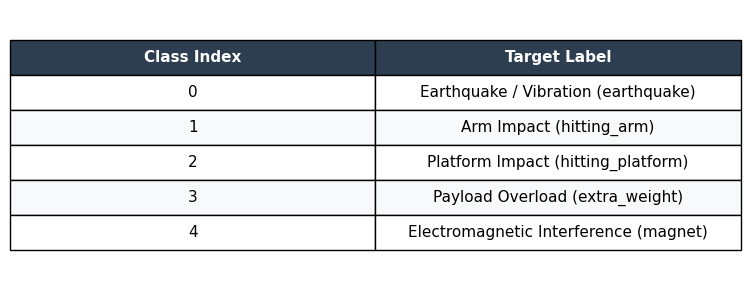

In [34]:
# Define dataset with required columns
label_data = {
    "Class Index": [0, 1, 2, 3, 4],
    "Target Label": [
        "Earthquake / Vibration (earthquake)",
        "Arm Impact (hitting_arm)",
        "Platform Impact (hitting_platform)",
        "Payload Overload (extra_weight)",
        "Electromagnetic Interference (magnet)"
    ]
}

df_labels = pd.DataFrame(label_data)

# Create figure and axis setup
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

# Render Matplotlib Table
table = ax.table(
    cellText=df_labels.values,
    colLabels=df_labels.columns,
    cellLoc='center',
    loc='center'
)

# Apply font sizing and scale
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 1.8)

# Apply custom visual styling (dark header and alternating row background)
for (row, col), cell in table.get_celld().items():
    # Header row formatting
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    # Alternating data rows formatting
    else:
        cell.set_facecolor('#f8f9fa' if row % 2 == 0 else '#ffffff')

# Adjust layout and save high-resolution figure
plt.tight_layout()
plt.savefig('categorical_labels_table.png', dpi=300, bbox_inches='tight')
plt.show()

In [115]:
# Autoencoder Arkitecture 

input_shape = (WINDOW_SIZE, 9)

# Encoder
inputs = layers.Input(shape=input_shape)
x = layers.Conv1D(filters=16, kernel_size=3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(pool_size=2, padding='same')(x)
x = layers.Conv1D(filters=8, kernel_size=3, activation='relu', padding='same')(x)
encoded = layers.MaxPooling1D(pool_size=2, padding='same')(x)

# Decoder
x = layers.Conv1D(filters=8, kernel_size=3, activation='relu', padding='same')(encoded)
x = layers.UpSampling1D(size=2)(x)
x = layers.Conv1D(filters=16, kernel_size=3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(size=2)(x)
decoded = layers.Conv1D(filters=9, kernel_size=3, activation='linear', padding='same')(x)

autoencoder = models.Model(inputs, decoded, name="Autoencoder_1D")
autoencoder.compile(optimizer='adam', loss='mse')

# Training with the Normal Data (train_win)
autoencoder.fit(
    train_win, train_win,
    epochs=30,
    batch_size=32,
    validation_data=(val_win, val_win),
    verbose=1
)

# Treshold calculation based on the validation set
val_pred = autoencoder.predict(val_win)
val_mse = np.mean(np.square(val_win - val_pred), axis=(1, 2))
THRESHOLD = np.percentile(val_mse, 98)  # Percentil 98 como umbral de normalidad
print(f"Umbral MSE para anomalías: {THRESHOLD:.5f}")

Epoch 1/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step - loss: 0.2299 - val_loss: 0.0784
Epoch 2/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step - loss: 0.0580 - val_loss: 0.0466
Epoch 3/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 629us/step - loss: 0.0401 - val_loss: 0.0362
Epoch 4/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 633us/step - loss: 0.0329 - val_loss: 0.0307
Epoch 5/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - loss: 0.0289 - val_loss: 0.0276
Epoch 6/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step - loss: 0.0263 - val_loss: 0.0256
Epoch 7/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - loss: 0.0245 - val_loss: 0.0240
Epoch 8/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step - loss: 0.0232 - val_loss: 0.0229
Epoch 9/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 669us/step - loss: 0.0223 - val_loss: 0.0220
Epoch 10/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - loss: 0.0215 - val_loss: 0.0213
Epoch 11/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step - loss: 0.0209 - val_loss: 0.0207
Epoch 12/30
820/820 ━━━━━━━━━━

Epoch 1/47
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4751 - loss: 1.2230 - val_accuracy: 0.5272 - val_loss: 1.1643 - learning_rate: 5.0000e-04
Epoch 2/47
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5607 - loss: 0.9796 - val_accuracy: 0.5956 - val_loss: 0.9937 - learning_rate: 5.0000e-04
Epoch 3/47
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6078 - loss: 0.8986 - val_accuracy: 0.5894 - val_loss: 0.9320 - learning_rate: 5.0000e-04
Epoch 4/47
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6335 - loss: 0.8441 - val_accuracy: 0.6579 - val_loss: 0.8877 - learning_rate: 5.0000e-04
Epoch 5/47
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6654 - loss: 0.7988 - val_accuracy: 0.6719 - val_loss: 0.8606 - learning_rate: 5.0000e-04
Epoch 6/47
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6891 - loss: 0.7549 - val_accuracy: 0.6672 - val_loss: 0.8141 - learning_rate: 5.0000e-04
Epoch 7/47
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7000 - loss:

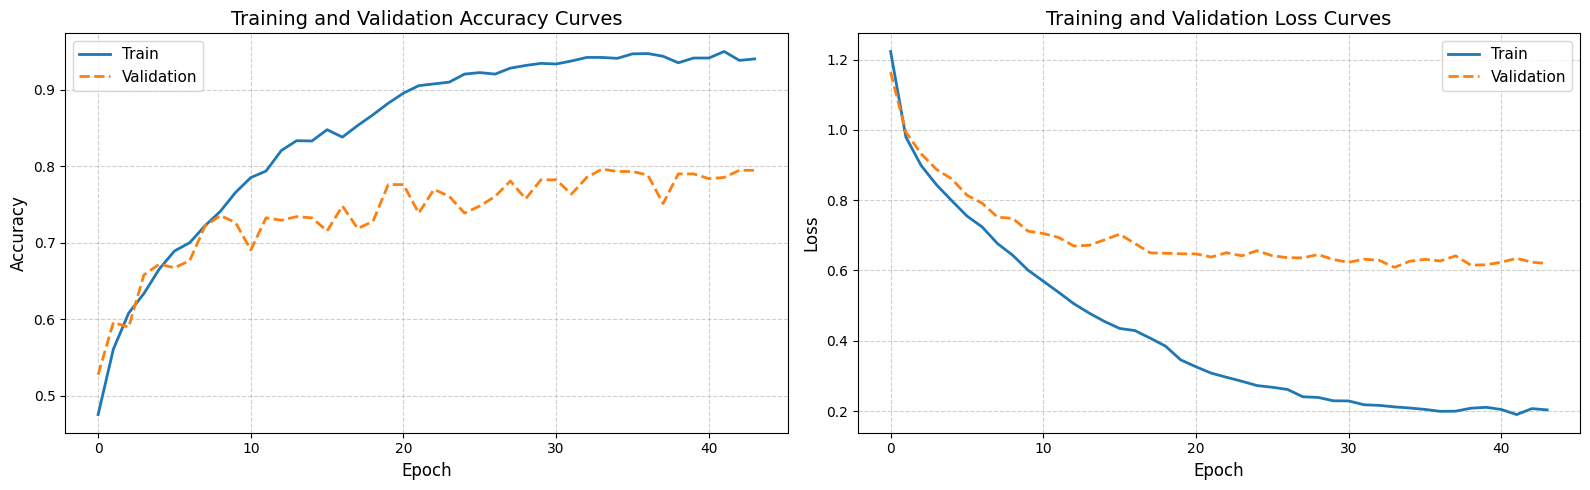

In [ ]:
#  CNN Architecture 

# fixing the Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# separate stratified the faliurs data (solving the possible Overfitting problem)

# spliting the data into 80% training and 20% validation, stratified by class labels
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_failures, 
    y_failures, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_failures
)


# 3. CNN Architecture (L2 = 1e-3, Dropout = 0.3)

clf_inputs = layers.Input(shape=input_shape)

# layer Gaussian noise (5% white noise in training)
x = layers.GaussianNoise(0.05)(clf_inputs)

# Block 1: Kernels size 5 (L2 1e-4)
x = layers.Conv1D(
    32,
    kernel_size=5,
    padding='same',
    kernel_regularizer=regularizers.l2(1e-4),
)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(2)(x)

# Block 2: Kernels size 3
x = layers.Conv1D(
    64,
    kernel_size=3,
    padding='same',
    kernel_regularizer=regularizers.l2(1e-4),
)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(2)(x)

# Block 3: Deep Feature Extraction
x = layers.Conv1D(
    128,
    kernel_size=3,
    padding='same',
    kernel_regularizer=regularizers.l2(1e-4),
)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

# Dual Pooling (captures peaks and trends)
avg_pool = layers.GlobalAveragePooling1D()(x)
max_pool = layers.GlobalMaxPooling1D()(x)
x = layers.concatenate([avg_pool, max_pool])

# Dense Layer (Dropout 0.3)
x = layers.Dense(
    64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)
)(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation='softmax')(x)

classifier = models.Model(
    clf_inputs, outputs, name='Classifier_1D_Calibrated'
)

# Compile with Learning Rate of 0.0005
classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)


# Callbacks

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,  
        min_lr=1e-5,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,  #
        restore_best_weights=True,
        verbose=1,
    ),
]


# 4. Training 

history = classifier.fit(
    X_train_clf,
    y_train_clf,
    validation_data=(X_val_clf, y_val_clf),
    epochs=47,  
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)


# Visualization of Training and Validation Curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica 1: Precisión (Accuracy)
ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(
    history.history['val_accuracy'],
    label='Validation',
    linewidth=2,
    linestyle='--',
)
ax1.set_title('Training and Validation Accuracy Curves', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)

# Gráfica 2: Pérdida (Loss)
ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(
    history.history['val_loss'],
    label='Validation',
    linewidth=2,
    linestyle='--',
)
ax2.set_title('Training and Validation Loss Curves', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Hibrid Pipeline: Autoencoder + Classifier

class KerasHybridPipeline:
    def __init__(self, autoencoder, classifier, threshold, class_labels):
        self.autoencoder = autoencoder
        self.classifier = classifier
        self.threshold = threshold
        self.class_labels = class_labels

    def predict(self, input_windows):
        """
        input_windows: Array Numpy 3D (muestras, WINDOW_SIZE, 9)
        """
        # 1. Reconstrucción con el Autoencoder
        reconstructions = self.autoencoder.predict(input_windows, verbose=0)
        
        # 2. Calculating the MSE for each window
        mse_errors = np.mean(np.square(input_windows - reconstructions), axis=(1, 2))
        
        results = []
        for i, mse in enumerate(mse_errors):
            if mse <= self.threshold:
                # is is under the threshold, classify as normal
                results.append({
                    "window_idx": i,
                    "status": "NORMAL",
                    "mse_error": float(mse),
                    "diagnosis": None
                })
            else:
                # 3. if is over treshold, classify the window with the CNN classifier
                window_sample = input_windows[i:i+1]
                probs = self.classifier.predict(window_sample, verbose=0)
                pred_class = np.argmax(probs, axis=1)[0]
                
                results.append({
                    "window_idx": i,
                    "status": "ANOMALÍA DETECTADA",
                    "mse_error": float(mse),
                    "diagnosis": self.class_labels.get(pred_class, "Desconocida")
                })
                
        return results

# Faliure mapping
labels_map = {
    0: "Terremoto / Vibración (earthquake)",
    1: "Golpe en el Brazo (hitting_arm)",
    2: "Golpe en la Plataforma (hitting_platform)",
    3: "Peso Extra (extra_weight)",
    4: "Interferencia Magnética (magnet)"
}

# Pipeline initialization
pipeline = KerasHybridPipeline(autoencoder, classifier, THRESHOLD, labels_map)

# testing inference with a sample of normal and failure windows
sample_test = np.concatenate([test_win[:2], hit_win[:2]], axis=0)
predictions = pipeline.predict(sample_test)

for res in predictions:
    print(res)

{'window_idx': 0, 'status': 'NORMAL', 'mse_error': 0.02746378361294104, 'diagnosis': None}
{'window_idx': 1, 'status': 'NORMAL', 'mse_error': 0.04399811214485421, 'diagnosis': None}
{'window_idx': 2, 'status': 'ANOMALÍA DETECTADA', 'mse_error': 0.08834156209759166, 'diagnosis': 'Golpe en el Brazo (hitting_arm)'}
{'window_idx': 3, 'status': 'ANOMALÍA DETECTADA', 'mse_error': 0.0917165103482697, 'diagnosis': 'Golpe en el Brazo (hitting_arm)'}


In [136]:
print(f"Total Anomaly Windows (N_total): {X_failures.shape[0]}")
print(f"Training Anomaly Windows (N_train): {X_train_clf.shape[0]}")
print(f"Validation Anomaly Windows (N_val): {X_val_clf.shape[0]}")

Total Anomaly Windows (N_total): 3213
Training Anomaly Windows (N_train): 2570
Validation Anomaly Windows (N_val): 643


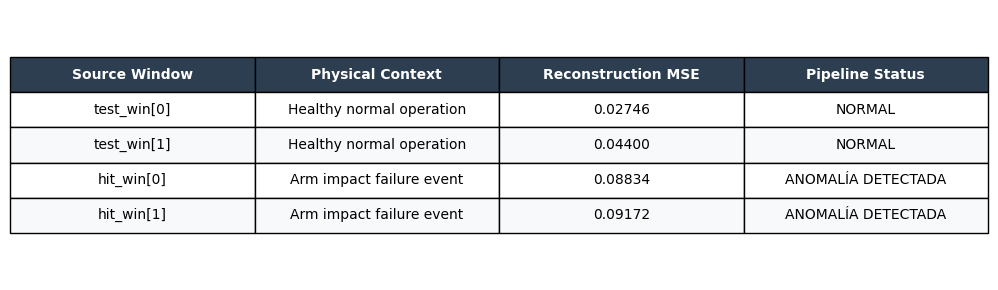

In [213]:
# 1. Create the DataFrame with the prediction data
sample_test = np.concatenate([test_win[:2], hit_win[:2]], axis=0)
predictions = pipeline.predict(sample_test)

metadata = [
    {
        'source': 'test_win[0]',
        'context': 'Healthy normal operation',
    },
    {
        'source': 'test_win[1]',
        'context': 'Healthy normal operation',
    },
    {
        'source': 'hit_win[0]',
        'context': 'Arm impact failure event',
    },
    {
        'source': 'hit_win[1]',
        'context': 'Arm impact failure event',
    },
]

table_data = []
for idx, res in enumerate(predictions):
    table_data.append({
        'Source Window': metadata[idx]['source'],
        'Physical Context': metadata[idx]['context'],
        'Reconstruction MSE': f"{res.get('mse_error', 0.0):.5f}",
        'Pipeline Status': res.get('status', 'N/A'),
    })

df_inference = pd.DataFrame(table_data)

# 2. Render the table with Matplotlib
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

# Create the table (Omit rowLabels to remove the index column)
table = ax.table(
    cellText=df_inference.values,
    colLabels=df_inference.columns,
    cellLoc='center',
    loc='center',
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Apply visual formatting to header and alternating rows
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    else:
        cell.set_facecolor('#f8f9fa' if row % 2 == 0 else '#ffffff')

plt.tight_layout()

# Save to PDF
fig.savefig(
    'Graphics_supervised/Expected_Inference_Results.pdf',
    format='pdf',
    bbox_inches='tight',
)
plt.show()

In [139]:
def plot_all_continuous_failures_mse(
    failures_raw_dict,
    pipeline,
    scaler_X,
    window_size=128,
    step=16,
    sampling_rate_hz=100.0,
    save_path='Graphics_supervised/Continuous_All_Failures_MSE.pdf',
):
  """Plots continuous Reconstruction MSE vs Threshold across the full duration of all 5 raw failure datasets.

  Parameters:
  -----------
  failures_raw_dict : dict
      Dictionary of unwindowed DataFrames:
      {'Earthquake': df_earthquake, 'Hitting Arm': df_hitting_arm, ...}
  pipeline : object
      Integrated Autoencoder + CNN pipeline model.
  scaler_X : StandardScaler
      Fitted scaler used during training.
  window_size : int
      Length of sliding window (default: 128).
  step : int
      Stride step between windows (default: 16).
  sampling_rate_hz : float
      Sensor sampling rate in Hz (default: 100.0 Hz).
  save_path : str
      Output path for vector PDF figure.
  """
  num_failures = len(failures_raw_dict)
  threshold = getattr(pipeline, 'threshold', 0.035)

  fig, axes = plt.subplots(
      num_failures, 1, figsize=(12, 2.3 * num_failures), sharex=False
  )

  if num_failures == 1:
    axes = [axes]

  colors = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

  for idx, (fault_name, df_raw) in enumerate(failures_raw_dict.items()):
    ax = axes[idx]

    # 1. Scale raw continuous signal
    raw_values = (
        df_raw.values if isinstance(df_raw, pd.DataFrame) else np.array(df_raw)
    )
    scaled_signal = scaler_X.transform(raw_values)

    # 2. Extract continuous sliding windows & calculate Reconstruction MSE
    time_stamps = []
    mse_errors = []
    total_samples = len(scaled_signal)

    for start_idx in range(0, total_samples - window_size + 1, step):
      end_idx = start_idx + window_size
      window = scaled_signal[start_idx:end_idx]

      # Midpoint timestamp for current window
      window_center_sec = (start_idx + window_size / 2.0) / sampling_rate_hz

      # Pipeline prediction on window
      win_input = np.expand_dims(window, axis=0)
      res = pipeline.predict(win_input)[0]

      time_stamps.append(window_center_sec)
      mse_errors.append(res.get('mse_error', 0.0))

    time_stamps = np.array(time_stamps)
    mse_errors = np.array(mse_errors)

    # 3. Plot Reconstruction MSE
    line_color = colors[idx % len(colors)]
    ax.plot(
        time_stamps,
        mse_errors,
        color=line_color,
        linewidth=1.5,
        label=f'{fault_name} MSE',
    )

    # 4. Anomaly Threshold Line
    ax.axhline(
        y=threshold,
        color='black',
        linestyle='--',
        linewidth=1.2,
        label=f'Threshold ({threshold:.4f})',
    )

    # 5. Highlight Failure Active Regions (MSE > Threshold)
    anom_mask = mse_errors > threshold
    max_y = max(np.max(mse_errors) * 1.15, threshold * 1.5)
    ax.fill_between(
        time_stamps,
        0,
        max_y,
        where=anom_mask,
        color='#e74c3c',
        alpha=0.2,
        label='Anomaly Detected',
    )

    # Formatting Subplots
    ax.set_ylabel('Reconstruction MSE', fontsize=9, fontweight='bold')
    ax.set_title(
        f'Fault Dataset: {fault_name}',
        fontsize=11,
        fontweight='bold',
        loc='left',
        pad=4,
    )
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', frameon=True, fontsize=8)

  # Common X-axis label
  axes[-1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')

  plt.tight_layout()

  # Save vector PDF
  if save_path:
    fig.savefig(save_path, format='pdf', bbox_inches='tight')
    print(f'Continuous MSE plot saved successfully to: {save_path}')

  plt.show()


# ==============================================================================
# Execution Example
# ==============================================================================
# Map the full unwindowed raw DataFrames
failures_raw_dict = {
    'Earthquake': df_earthquake,
    'Hitting Arm': df_hitting_arm,
    'Hitting Platform': df_hitting_platform,
    'Extra Weight': df_extra_weight,
    'Magnet Interference': df_magnet,
}

# Run multi-panel continuous time-domain evaluation
plot_all_continuous_failures_mse(
    failures_raw_dict=failures_raw_dict,
    pipeline=pipeline,
    scaler_X=scaler_X,
    window_size=128,
    step=16,
    sampling_rate_hz=100.0,  # Match your sensor sampling frequency (Hz)
    save_path='Graphics_Hibrid/1_Continuous_All_Failures_MSE.pdf',
)

NameError: name 'pipeline' is not defined

Full signal pointwise MSE plot saved to: Graphics_supervised/All_Failures_Pointwise_MSE_vs_Time.pdf


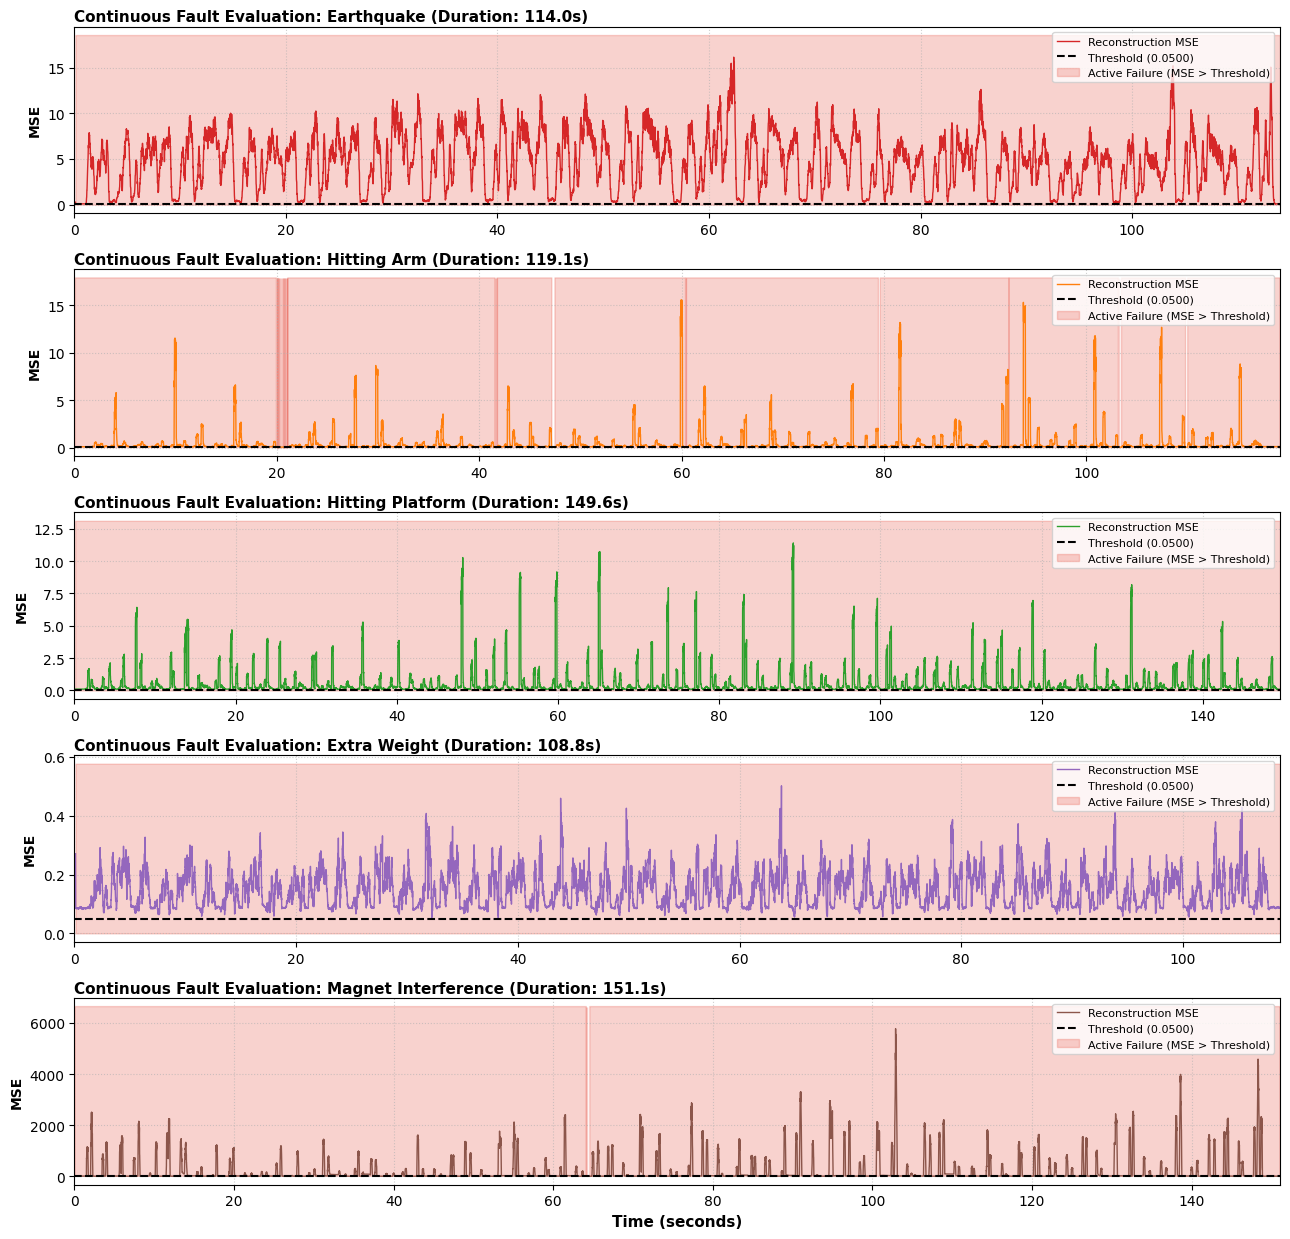

In [ ]:
def plot_pointwise_continuous_mse(
    failures_scaled_dict,
    pipeline,
    window_size=20,
    sampling_rate_hz=100.0,
    save_path='Graphics_supervised/All_Failures_Pointwise_MSE_vs_Time.pdf',
):
  """Calculates and plots pointwise Reconstruction MSE vs Threshold across the full duration of all 5 scaled failure datasets.
  """
  num_failures = len(failures_scaled_dict)
  threshold = getattr(pipeline, 'threshold', 0.035)

  fig, axes = plt.subplots(
      num_failures, 1, figsize=(13, 2.5 * num_failures), sharex=False
  )

  if num_failures == 1:
    axes = [axes]

  colors = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

  for idx, (fault_name, scaled_signal) in enumerate(
      failures_scaled_dict.items()
  ):
    ax = axes[idx]

    data = (
        scaled_signal.values
        if isinstance(scaled_signal, pd.DataFrame)
        else np.array(scaled_signal)
    )

    total_samples = len(data)

    # 1. create sliding windows for the entire signal (no overlap)
    num_windows = total_samples - window_size + 1
    windows = np.array([data[i : i + window_size] for i in range(num_windows)])

    # 2. Interference with the Autoencoder to get reconstructions

    reconstructions = pipeline.autoencoder.predict(windows, verbose=0)

    # 3. caculate MSE for each window (pointwise)
    mse_errors = np.mean(
        np.square(windows - reconstructions), axis=(1, 2)
    )

    # 4. Aassig each window to its corresponding time in seconds (center of the window)
    time_seconds = (
        np.arange(num_windows) + (window_size / 2.0)
    ) / sampling_rate_hz

    # 5. Graph the pointwise MSE over time

    line_color = colors[idx % len(colors)]
    ax.plot(
        time_seconds,
        mse_errors,
        color=line_color,
        linewidth=1.0,
        label='Reconstruction MSE',
    )

    # 6. mark the anomaly detection threshold line

    ax.axhline(
        y=threshold,
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Threshold ({threshold:.4f})',
    )

    # 7. drwaw the active failure regions (MSE > Threshold)
    anom_mask = mse_errors > threshold
    max_y = max(np.max(mse_errors) * 1.15, threshold * 1.5)
    ax.fill_between(
        time_seconds,
        0,
        max_y,
        where=anom_mask,
        color='#e74c3c',
        alpha=0.25,
        label='Active Failure (MSE > Threshold)',
    )

    # Formatting Subplots
    ax.set_xlim(left=0, right=np.max(time_seconds))
    ax.set_ylabel('MSE', fontsize=10, fontweight='bold')
    ax.set_title(
        f'Continuous Fault Evaluation: {fault_name} (Duration:'
        f' {np.max(time_seconds):.1f}s)',
        fontsize=11,
        fontweight='bold',
        loc='left',
        pad=4,
    )
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', frameon=True, fontsize=8)

  axes[-1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
  plt.tight_layout()

  if save_path:
    fig.savefig(save_path, format='pdf', bbox_inches='tight')
    print(f'Full signal pointwise MSE plot saved to: {save_path}')

  plt.show()


#ploting the pointwise continuous MSE for all failures

failures_scaled_dict = {
    'Earthquake': Falure_erq,
    'Hitting Arm': Falure_hit,
    'Hitting Platform': Falure_plat,
    'Extra Weight': Falure_weight,
    'Magnet Interference': Falure_magnet,
}

plot_pointwise_continuous_mse(
    failures_scaled_dict=failures_scaled_dict,
    pipeline=pipeline,
    window_size=20,  # Tu tamaño de ventana de 20 muestras
    sampling_rate_hz=100.0,
)